# UseCase
To predict if a person will have a certain type of disease or not

In [ ]:
* Actual a person was having NO Disease but model predicted Diseased.
* Actual a person was having Diease but model predicted NOt Diseased.

In [ ]:
Here we need to focus on Recall of the model.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report


In [5]:
data = pd.read_csv('health_lifestyle_dataset.csv')

In [5]:
data

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,Male,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0
99996,99997,22,Male,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0
99997,99998,37,Male,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0
99998,99999,72,Female,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0


In [7]:
data.columns

Index(['id', 'age', 'gender', 'bmi', 'daily_steps', 'sleep_hours',
       'water_intake_l', 'calories_consumed', 'smoker', 'alcohol',
       'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol',
       'family_history', 'disease_risk'],
      dtype='object')

In [ ]:
df.disease_risk.value_counts()

# Basic Checks
# Domain Analyis
# EDA

In [ ]:
data = df.sample(frac=0.5, random_state=42) ## Load the data when RAM is 4GB

In [ ]:
data.head()

In [16]:
data

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,Male,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0
99996,99997,22,Male,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0
99997,99998,37,Male,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0
99998,99999,72,Female,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0


## Data Preprocessing


*  Handle missing values.
*  Remove duplicates.
*  Convert categorical data to numerical.
*  Hanlde outliers.
*  Perform  feature scaling.
*  Balance the data incase of classification.
  

In [11]:
# Check if any missing values
data.isnull().sum()

id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64

In [13]:
# Check for duplicates
duplicates = data[data.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [id, age, gender, bmi, daily_steps, sleep_hours, water_intake_l, calories_consumed, smoker, alcohol, resting_hr, systolic_bp, diastolic_bp, cholesterol, family_history, disease_risk]
Index: []


In [18]:
pd.crosstab(df['gender'],df['disease_risk'])

disease_risk,0,1
gender,,
Female,37448,12420
Male,37731,12401


In [15]:
# Categorical data conversion
# Using one hot encoding as gender is equally important to detemrine if the person will be diseased or not

data = pd.get_dummies(data, columns=['gender'],dtype=int) # drop_first=True

In [17]:
data

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,gender_Female,gender_Male
0,1,56,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,0,1
1,2,69,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,1,0
2,3,46,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,0,1
3,4,32,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,1,0
4,5,60,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0,0,1
99996,99997,22,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0,0,1
99997,99998,37,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0,0,1
99998,99999,72,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0,1,0


In [ ]:
# Why scaling is needed?
# Types of scaling

In [24]:
data = data[['age', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l',
       'calories_consumed', 'smoker', 'alcohol', 'resting_hr', 'systolic_bp',
       'diastolic_bp', 'cholesterol', 'family_history','gender_Female','disease_risk' ]]


In [26]:
data

,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,gender_Female,disease_risk
0,56,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,0
1,69,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,1,0
2,46,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,0
3,32,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,1,0
4,60,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,53,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0,0
99996,22,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0,0
99997,37,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0,0
99998,72,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,1,0


In [19]:
## get the independent and dependent variable
X=data.iloc[:, :-1]
y=data['disease_risk']
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    1
Name: disease_risk, Length: 100000, dtype: int64

In [21]:
 # Split dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# Model object creation
model = SVC(kernel='rbf', C=1.0, gamma='scale')  # default SVM settings


In [25]:

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [29]:
data.disease_risk.value_counts()

disease_risk
0    75179
1    24821
Name: count, dtype: int64

In [27]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86     15036
           1       0.00      0.00      0.00      4964

    accuracy                           0.75     20000
   macro avg       0.38      0.50      0.43     20000
weighted avg       0.57      0.75      0.65     20000



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Cross Validation

Cross-validation (CV) is a model evaluation technique used to check how well your machine learning model generalizes to unseen data.

It helps prevent overfitting (when a model performs well on training data but poorly on new data).

The basic idea

Instead of splitting your dataset into just train and test once,
cross-validation splits your data into multiple smaller train/test sets, trains the model multiple times, and averages the results.

Let’s say you use 5-fold cross-validation.

The dataset is divided into 5 equal parts (called folds).

The model is trained 5 times:

Each time, 4 folds are used for training,

and 1 fold is used for testing (rotating which fold is the test set).

The average accuracy across the 5 runs is your model’s performance.

Fold 1 → Train on [2,3,4,5], Test on [1]
Fold 2 → Train on [1,3,4,5], Test on [2]
Fold 3 → Train on [1,2,4,5], Test on [3]
Fold 4 → Train on [1,2,3,5], Test on [4]
Fold 5 → Train on [1,2,3,4], Test on [5]


Then you average the 5 test accuracies to get a more reliable score.

 Why Cross-Validation is useful
Benefit                    	Description
Better evaluation	        Uses the entire dataset for both training and testing (at different times).
Less bias	                Reduces dependency on one random train-test split.
Prevents overfitting	    You can detect models that only perform well on certain splits.
Used for tuning	Essential during GridSearchCV or RandomizedSearchCV for hyperparameter optimization.

In [ ]:
# Create pipeline (SVM)
model = SVC(kernel='rbf', C=1.0)

# Perform 5-fold cross-validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

In [ ]:
scores

In [ ]:
print("Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

# Hyperparameters of SVM

1. C (Regularization parameter)

Think of C as how strict SVM should be about mistakes.

Small C → SVM is okay with some mistakes → tries to make the margin wider (more general,
less overfitting)

Large C → SVM tries to classify every point correctly → margin might be smaller → can overfit

Analogy:
C is like a teacher:

Small C → teacher is relaxed, okay if a few students fail

Large C → teacher is strict, every student must get it right

2. Kernel (Type of SVM line)

Kernel decides how SVM draws the boundary between classes.

'linear' → straight line (or plane in higher dimensions)

'rbf' → curved, flexible boundary (good for complex patterns)

'poly' → polynomial curve (like a stretched curve)

'sigmoid' → S-shaped curve

Analogy:
Kernel is like the shape of the fence you build around different groups of points.

3. Gamma (for RBF/Poly/Sigmoid kernels)

Gamma controls how far the influence of a single training point reaches.

Small gamma → each point has wide influence → smoother boundary

Large gamma → each point has narrow influence → very tight, wiggly boundary (can overfit)
 Analogy:
Gamma is like spray range:

Small → spray covers a large area (smooth decision)

Large → spray hits only tiny area (wiggly, precise)

 4. Degree (only for poly kernel)

Degree decides the power of the polynomial curve.

Higher degree → more complex curve

Lower degree → simpler curve

Analogy:
Degree is like the bendiness of a road:

Degree 2 → gentle curve

Degree 5 → very twisty road

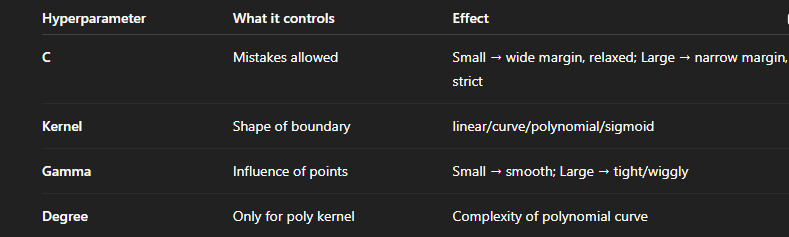


Rule of thumb:

Start with C=1, gamma='scale', kernel='rbf'.

Adjust only if your model is underfitting (too simple) or overfitting (too complex).

In [ ]:
# Model Object
pipe = SVC() 

# Grid of hyperparameters
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Grid search with 5-fold CV
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Train the model
grid.fit(X_train, y_train)

print("Best parameters (GridSearch):", grid.best_params_)
print("Best CV score:", grid.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [ ]:

from scipy.stats import uniform

# Define distribution for random search
param_dist = {
    'svm__C': uniform(0.1, 10),     # continuous range from 0.1 to 10
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto']
}

# Randomized search with 10 iterations and 5-fold CV
random_search = RandomizedSearchCV(pipe, param_distributions=param_dist,
                                   n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Best parameters (RandomizedSearch):", random_search.best_params_)
print("Best CV score:", random_search.best_score_)
